# Automatische Erkennung von Katastrophenmeldungen auf Twitter

Projektarbeit - Artificial Intelligence
Kaggle Challenge: *Natural Language Processing with Disaster Tweets*


## 1. Kontext & Problemstellung

Soziale Medien wie Twitter spielen in Not- und Krisensituationen eine immer wichtigere Rolle. Durch die weitere Verbreitung von Smartphones können Augenzeugen Ereignisse wie Naturkatastophen, Brände oder Unfälle in Echtzeit melden. 

Für Hilfsorganisationen, Behörden und Nachrichtenagenturen ist jedoch schwierig automatisch zu erkennen, ob ein Tweet tatsächlich eine reale Katastrophe beschreibt oder ob Begriffe wie 'fire', 'flood' oder explosion lediglich metaphorisch verwendet werden. 

Da täglich grosse Mengen an Tweets erzeugt werden, ist eine manuelle Überwachung nicht skalierbar. Aus diesem Grund besteht ein grosses Interesse an automatisierten Systemen, die relevante Katastrophen zuverlässig identifizieren können.

## 2. Fragestellung 

Die zentrale Fragestellung dieses Projektes lautet: 

Lassen sich Tweets mithilfe von Natural Language Processing (NLP) und Machine-Learning-Verfahren zuverlässig in 'reale Katastrophe' und 'keine Katastrophe' klassifizieren?

## 3. Zielsetzung & Evaluationsmetrik

Ziel dieses Projekts ist es, ein Klassifikationsmodell zu entwicklen, das Tweets korrekt danach einordnet, ob sie sich auf reale Katastrophen beziehen oder nicht. 

Als Evaluationsmetrik wird der F1-Score verwendet, weil Precision und Recall gleichzeitig relevant sind. In einem realen Einsatz sind insbesondere False Negatives kritisch, da echt Katastrophenmeldungen übersehen würden. Daher ist nicht nur die Klassenimbalance, sondern vor allem die Fehlerart (FN vs FP) entscheidend.

## 4. Datensatz 
Der verwendete Datensatz stammt aus der Kaggle-Challenge 'Natrual Language Processing with Diaster Tweets'. 

Jeder Eintrag entspricht ein Tweet und enthält under anderem:
-den Text des Tweets
-optionale Zusatzinformationen wie Keyword oder Location 
-ein label ('target'), das angibt ob es sich um eine reale Katastrophe handelt (1) oder nicht (0)

Der Datensatz ist für eine binäre Textklassifikation ausgelegt.

## 5. Erste Exploration der Daten

Im folgenden Abschnitt werden die Struktur und grundlegende Eigenschaften des Datensatzes untersucht, um ein besseres Verständnis der Datenbasis für die Modellierung zu erhalten.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#daten laden
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

train.shape, test.shape

((7613, 5), (3263, 4))

In [10]:
#Überblick über den Trainingsdatensatz
train.head(), train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


(   id keyword location                                               text  \
 0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
 1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
 2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
 3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
 4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   
 
    target  
 0       1  
 1       1  
 2       1  
 3       1  
 4       1  ,
 None)

In [11]:
#Klassenverteilung 
target_counts = train['target'].value_counts()
target_counts

target
0    4342
1    3271
Name: count, dtype: int64

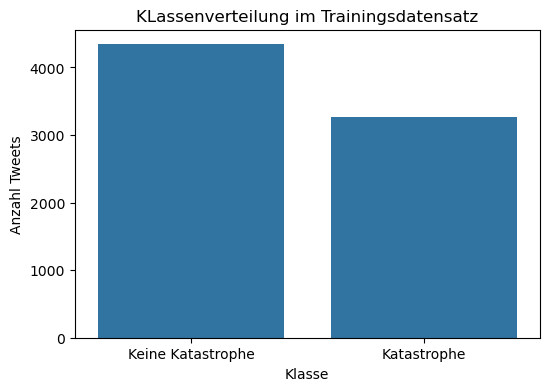

In [12]:
plt.figure(figsize=(6, 4))
sns.barplot(
    x=target_counts.index,
    y=target_counts.values
)
plt.xticks([0, 1], ['Keine Katastrophe', 'Katastrophe'])
plt.ylabel('Anzahl Tweets')
plt.xlabel('Klasse')
plt.title('KLassenverteilung im Trainingsdatensatz')
plt.show()

Die Klassenverteilung ist nicht vollständig ausgeglichen. 
Es gibt leicht mehr Tweets ohne reale Katastrophe als mit Katastrophe. 
Aus diesem Grund ist die Accuarcy als alleinige Metrik nicht geeignet, weshalb im weiteren Verlauf der F1-Score verwendet wird

In [13]:
#Textlänge (Anzahl Zeichen)
train['text_length'] = train['text'].apply(len)
train[['text', 'text_length']].head()

,text,text_length
0,Our Deeds are the Reason of this #earthquake M...,69
1,Forest fire near La Ronge Sask. Canada,38
2,All residents asked to 'shelter in place' are ...,133
3,"13,000 people receive #wildfires evacuation or...",65
4,Just got sent this photo from Ruby #Alaska as ...,88


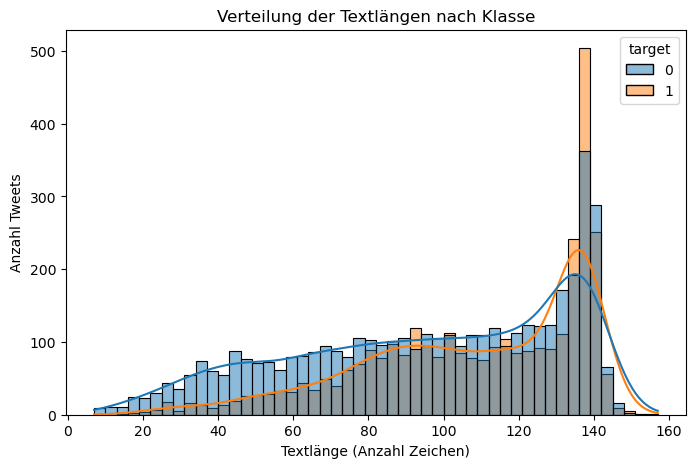

In [14]:
#Textlänge nach Klasse vergleichen 

plt.figure(figsize=(8, 5))
sns.histplot(
    data=train,
    x='text_length',
    hue='target',
    bins = 50,
    kde = True
)
plt.xlabel('Textlänge (Anzahl Zeichen)')
plt.ylabel('Anzahl Tweets')
plt.title('Verteilung der Textlängen nach Klasse')
plt.show()

In [15]:
#Durchschnittliche Textlänge pro Klasse
train.groupby('target')['text_length'].mean()

target
0     95.706817
1    108.113421
Name: text_length, dtype: float64

Tweets, die reale Katastrophen beschreiben, sind im Durchscnitt etwas länger als Tweets ohne Katastrophenbezug. 
Dies deutet darauf hin, dass zustätzliche Kontextinformationen eine Rolle spielen können, was für komplexere Modelle relevant sein könnte.

In [16]:
# Anteil fehlende Werte pro Spalte
train.isna().mean()

id             0.000000
keyword        0.008013
location       0.332720
text           0.000000
target         0.000000
text_length    0.000000
dtype: float64

Die Spalte 'Keyword' und 'Location' enthalten viele fehlende Werte. Im weiteren Verlauf wird der Fokus daher primär auf den Textinhalt der Tweets gelegt. 
Optionale Zusatzinformationen könnten später seperat untersucht werden, werden jedoch für die Basleine nicht berücksichtigt. 

## 6. Fazit der explorative Datenanalyse

Die explorative Analyse zeigt, dass: 
-ein moderates Klassengleichgewicht vorliegt
-Tweets kurze, aber informative Texte enthalten 
-der Textinhalt die zentrale Informationsquelle darstellt

Die Erkenntnisse bilden die Grundlage für die anschliessende Baseline-Modellierung mit TF-IDF und logistische Regressionsmodellen.

## 7. Baseline-Modell
Basierend auf den Erkenntnissen aus der explorativen Datenanalyse wird im folgenden Abschnitt ein Baseline-Modell zur Textklassifikation implementiert.

Das Ziel der Baseline ist es, eine einfache und gut interpretierbare Referenz zu schaffen, anhand derer komplexere Modelle spärter verglichen werden können.

Als Baseline wird ein klassischer NLP-Ansatz bestehend aus TF-IDF (Term Frequency - Inverse Document Frequency) und einer logistischen Regression verwendet. 

In [17]:
#Imports
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

In [18]:
#Features und Zielvariablen definieren 

X = train['text']
y = train['target']

#Trainings- und Validierungsdaten aufteilen
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42,
    stratify = y
)

In [19]:
# Pipeline: TF-IDF Vektorisierung + Logistische Regression 
baseline_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features = 10000,
        ngram_range = (1, 2),
        stop_words = 'english'
    )),
    ('clf', LogisticRegression(
        max_iter = 1000,
        solver = 'liblinear'
    ))
])

In [20]:
#Modell trainieren 
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000, solver='liblinear'))])

In [21]:
#Vorhersage erzeugen 
y_pred = baseline_model.predict(X_val)

In [22]:
#Precision, Recall, F1-Score
print(classification_report(y_val, y_pred, target_names=[
    'Keine Katastrophe',
    'Katastrophe'
]))

                   precision    recall  f1-score   support

Keine Katastrophe       0.80      0.90      0.85       869
      Katastrophe       0.84      0.70      0.76       654

         accuracy                           0.81      1523
        macro avg       0.82      0.80      0.81      1523
     weighted avg       0.82      0.81      0.81      1523



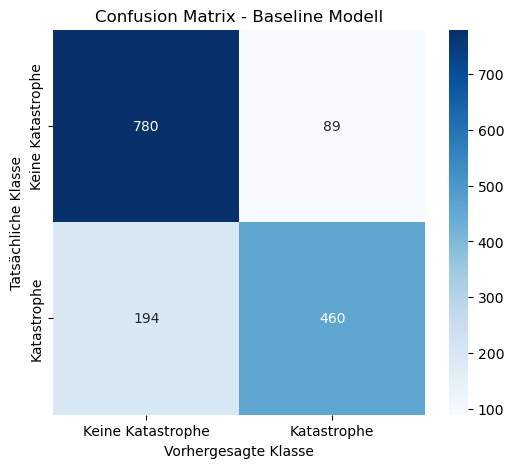

In [24]:
#Confusionsmatrix

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    xticklabels = ['Keine Katastrophe', 'Katastrophe'],
    yticklabels = ['Keine Katastrophe', 'Katastrophe']
)
plt.xlabel('Vorhergesagte Klasse')
plt.ylabel('Tatsächliche Klasse')
plt.title('Confusion Matrix - Baseline Modell')
plt.show()


## 8. Evaluation der Baseline

Das Baseline-Modell bestehend aus TF-IDF und logistischer Regression erreicht eine Accuracy von rund 80% sowie einen gewichteten F1-Score von 0.81. 
Die zeigt, dass bereits mit einem einfachen, wortbasierten Ansatz eine solide Klassifikationsleitung erzielt werden kann. 

Für die Klasse 'Keine Katastrophen' wird ein hoher Recall von 0.90 erreicht, was bedeutet, dass Tweets ohne realen Katastrophenbezug zuverlässig erkennt werden. Gleichzeitig liegt die Precision dieser Klasse bei 0.80, was auf vereinzelte Fehlalarme hinweist. 

Für die Klasse 'Katastrophe' ergibt sich eine Precision von 0.84 und ein Recall von 0.70. Das Midell erkennt somit einen Grossteil der tatsächlichen Katastrophen-Tweets korrekt, übersieht jedoch einen relevanten Anteil (False Negatives).

Die Confusion Matrix zeigt, dass inebesondere reale Katastrophenmeldungen teilweise fälschlicherweise als 'Keine Katastrophe' klassifiziert werden. Die deutet darauf hin, dass rein wortbasierte Merkmale bei impliziten oder kontextabhängige Formulierungen an ihre Grenzen stossen.

## 9. Zusammenfassung des Baseline-Modells
Mit dem TF-IDF + LogReg Ansatz wurde eine einfache, effiziente und gut interpretierbare Baseline für die Klassifikation von Disaster Tweets implementiert. 

Das Modell erzeilt eine solide Gesamtleistung, zeigt jedoch insbesondere bei der Erkennung realer Katastrophen Einschränkungen im Recall. 
Diese Beobachtung ist kritisch, da übersehene Katastrophenmeldungen in realen Anwendungsszenarien problematisch sein können. 

Die Baseline dient daher als klar definierter Referenzpunkt für den Einsatz komplexere Modelle, die semantische und kontextuelle Zusammenhänge besser erfassen können. 

## 10. Fehleranalyse und Zusatzanalyse

Aufbauend auf den Resultaten der Baseline-Modellierung wird im folgenden Abschnitt eine detailierte Fehleranalyse durchgeführt. 

Ziel ist es, typische Fehlklassifikationen systematisch zu untersuchen und besser zu verstehen, unter welchen Bedingungen das Modell scheitert. Diese Analyse dient als Grundlage für gezielte Modellverbesserungen.

### 10.1 Definition der Fehlertypen 

Für die Fehleranalyse werden folgende Fehlklassifikationen betrachtet: 

- **False Positives (FP):** Tweets, die fälschlicherweise als Katastrophe klassifiziert wurden.
- **False Negatives (FN:** Tweets, die eine reale Katastrophe beschreiben, jedoch als 'keine Katastrophe' klassifiziert wurden.

Insbesondere False Negatives sind kritisch, da reale Katastrophenmeldungen nicht erkennt wurden

In [25]:
# Validierungsdaten inkl. Vorhersagen zusammenführen

val_df = pd.DataFrame({
    'text' : X_val,
    'true_label' : y_val,
    'pred_label' : y_pred
})

#Fehlertyp bestimmen
val_df['error_type'] = 'Correct'
val_df.loc[(val_df.true_label == 0) & (val_df.pred_label == 1), 'error_type'] = 'False Positives'
val_df.loc[(val_df.true_label == 1) & (val_df.pred_label == 0), 'error_type'] = 'False Negatives'

pd.set_option("display.max_colwidth", None)
val_df.head()

,text,true_label,pred_label,error_type
4863,@TheEconomist Step one: get that mass murderer's portrait off the yuan.,0,1,False Positives
1370,Ted Cruz fires back at Jeb &amp; Bush: ÛÏWe lose because of Republicans like Jeb &amp; Mitt.Û [Video] - http://t.co/BFTHaHLCr0,0,0,Correct
3521,How ÛÏLittle BoyÛ Affected the People In Hiroshima ÛÒ Eyewitness Testimonials http://t.co/mUAnfWcRW9,1,1,Correct
178,AMBULANCE SPRINTER AUTOMATIC FRONTLINE VEHICLE CHOICE OF 14 LEZ COMPLIANT | eBay http://t.co/4evTTqPEia,0,0,Correct
5859,'Cause you play me like a symphony play me till your fingers bleed. I'm your greatest masterpiece. You ruin me??,0,0,Correct


In [26]:
val_df['error_type'].value_counts()

error_type
Correct            1240
False Negatives     194
False Positives      89
Name: count, dtype: int64

In [27]:
#Zufällige Beispiele für False Positives

fp_examples = val_df[val_df['error_type'] == 'False Positives']. sample(5, random_state=42)

fp_examples[['text']]

,text
4327,REVEALED: Everton hijack United bid for 14-year-old WONDERKID! - http://t.co/nb1E7mNcE5
6504,10 Ways To Survive and Escape Martial Law | World http://t.co/BiuEY7bUtS http://t.co/JWQYbe4ep1
1541,Google Alert: Emergency units simulate a chemical explosion at NU http://t.co/NDgpWYxu6H
2951,So today I fell off a rock scraped my whole butt and nearly drowned #summer2k15
6703,L B #Oklahoma #Thunder DURANT NBA ADIDAS OKLAHOMA CITY THUNDER YOUTH LARGE SWINGMAN JERSEY RETAIL $75 #NBA #Durant http://t.co/T81oayjoWC


In [28]:
pd.set_option("display.max_colwidth", None)


In [29]:
#Zufällige Beispiele für False Negatives

fn_examples = val_df[val_df['error_type'] == 'False Negatives']. sample(5, random_state=42)

fn_examples[['text']]

,text
5538,Some of worst radiation exposure from Fukushima meltdown happened 47km northwest-Proof that small emergency planning zones donÛªt cut it
6647,@SwiftyCommissh @TaoistInsight @ImmortalTech Some jewish ppl agree tht Israel is a bully nd a terrorist state killin palestine kids nd women
598,[JAX Biz Journal] FedEx stops shipping potential bioterror pathogens http://t.co/R33nCvjovC
7489,@GeorgeFoster72 and The Wreck of the Edmund Fitzgerald
5507,Reddit's new content policy goes into effect many horrible subreddits banned or quarantined http://t.co/ZsXqbdUzBN http://t.co/6NCfjXPLOY


### 10.2 Intepretation der Fehlklassifikation 

Die Analyse der False Positives zeigt, dass das Modell häufig auf einzelne stark gewichtete Schlüsselbegriffe reagiert, ohne den inhaltlichen Kontext des Tweets korrekt zu erfassen. 

Beispiele hierfür sind Tweets, die Begriffe wie 'emergency', 'explosion' oder 'martial law' enthalten, jedoch kein realen Katastrophenbezug haben, sondern sich auf Simulationen, Medienberichte, Sportereignisse oder reisserische Überschriften beziehen. Der TF-IDF-Ansatz interpretiert diese Begriffe isoliert und stuft den Tweet daher fälschlicherweise als Katastrophe ein. 

Die False Negatives verdeutlichen eine andere Schwäche des Modells. 
Mehrere dieser Tweets beschreiben reale, teils schwerwiegende Ereignisse (z.B. Fukushima-Strahlung, Bioterror-Gefahr oder politische Gewalt), verwenden jedoch keine klaren oder häufigen Katastrophen-Schlüsselwörter. Stattdessen sind die Beschreibungen komplex, indirekt oder stark kontextabhängig. 

Diese Beobachtungen zeigen, dass das Baseline-Modell insbesondere dann scheitert, wenn Bedeutung nicht durch einzelne Wörter, sondern durch den Gesamtzusammenhang des Textes entsteht. 

Damit wird eine zentrale Limitation des TF-IDF-Ansatzes sichtbar: 
Semantische Beziehungen, Ironie, indirekte Beschreibungen und KOntextinformationen können nur unzureichend abgebildet werden. 

In [30]:
#Textlänge berechnen 
val_df['text_length'] = val_df['text'].apply(len)

#Durchschnittliche Textlänge nach Fehlertyp
val_df.groupby('error_type')['text_length'].mean()

error_type
Correct            101.016129
False Negatives    100.474227
False Positives    100.247191
Name: text_length, dtype: float64

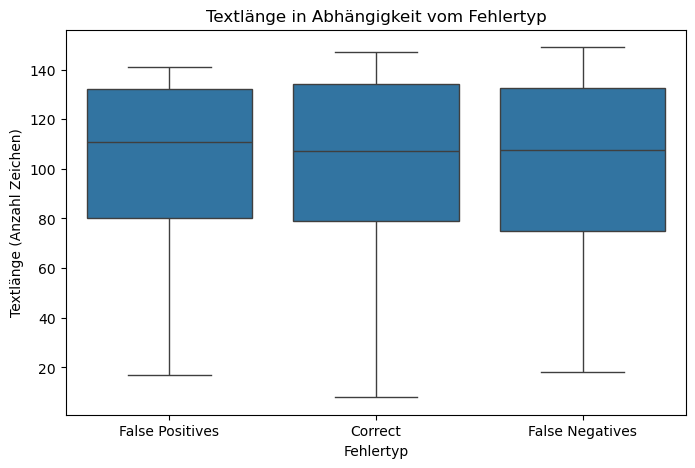

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(
    data = val_df, 
    x = 'error_type',
    y = 'text_length'
)
plt.xlabel('Fehlertyp')
plt.ylabel('Textlänge (Anzahl Zeichen)')
plt.title('Textlänge in Abhängigkeit vom Fehlertyp')
plt.show()

### 10.3 Zusatzanalyse: Textlänge vs. Modellfehler

Die Boxplot-Analyse zeigt, dass sich die Textlängen der drei Gruppen (False Positives, korrekt klassifizierte Tweets und False Negatives) stark Überlappen. 

Weder der Medien noch die Streuung der Textlängen unterscheiden sich signifikant zwischen den Fehlertypen. Insbesondere sind False Negative Tweets nicht systematisch länger als korrekt klassifizierte Tweets. 

Dies deutet darauf hin, dass die Textlänge allein keinen entscheidenden Einfluss aif die Fehler des Modells hat. Die beobachteten Fehlklassifikationen lassen sich somit nicht durch die Länge der Tweets erklären, sondern vielmehr durch inhaltliche und semantische Aspekte. 

Das Ergebnis unterstreicht, dass nicht die Menge des Textes, sondern die Art der sprachlichen Formulierung und der Kontext entscheidend für die Modellperformance sind. 

### 10.4 Diskussion der Resultate

Die Fehleranalyse zeigt, dass die Schwächen des Baseline-Modells nicht auf oberflächliche Eigenschaften wie die Textlänge zurückzuführen sind, sondern auf inhaltliche und semantische Limitationen. 

False Positives entstehen vor allem dann, wenn katastrophenassozierte Schlüsselwörter ausserhalb eines realen Erreigniskontexts verwendet werden. 
False Negatives treten hingegen häufig bei indirekten, komplexen oder kontextanhängigen Beschreibungen realer Ereignisse auf. 

Die Zusatzanalyse zur Textlänge bestätigt, dass strukturelle Merkmale der Tweets nur eine untergeordnete Rolle spielen, Entscheidend ist vielmehr, ob das Modell in der Lage ist, Bedeutung über einzelne Wörter hinaus zu erfassen. 

Damit wird deutlich, dass rein wortbasierte Ansätze wie TF-IDF grundlegende Grenzen besitzen, wenn semantisches Verständnis erforderlich ist.

## 11. Fazit der Fehleranalyse

Die detaillierte Fehleranalyse zeigt, dass das Baseline-Modell systematische Schäwchen bei der Interpretation von Kontext und Bedeutung aufweise. 

Während einzelne Schlüsselbegriffe zuverlässig erkannt werden, scheitert das Modell bei indirekten Formulierungen, Ironie und komplexen sprachlichen Zusammenhängen. Die Zusatzanalyse bestätigt zudem, dass diese Fehler nicht durch einfach struktuelle Merkmale wie die Textlänge erklärt werden können. 

Diese Erkenntnisse leifern eine klare Motivation für den Einsatz leistungsfähigerer Modelle, die sematische Beziehungen besser erfasen können. 
Im nächsten Abschnitt wird daher ein neuronales Netz zur Textklassifikation eingesetzt, um diese Limitationen gezielt anzugehen.

## 12. Neuronale Netze zur Textklassifikation

Die Fehleranalyse der Baseline hat gezeigt, dass rein wortbasierte Ansätze wie TF-IDF insbesondere bei indirekten, kontextanhängigen Formulierungen an ihre Grenzen stossen. 

Um sematische Zusammenhänge besser erfassen zu können, wird im folgenden Abschnitt ein neuronales Netz zur Textklassifikation eingesetzt. 
Konkret wird ein bidirektionales LSTM-Modell (Bi-LSTM) mit vortrainierten GloVe-Embeddungs verwendet.

LSTMs modellieren Sequenzen und können Abhängigkeiten über Wortpositionen hinweg lernen. Die bidirektionale Variante nutzt Kontext von links und rechts, was bei kurzen Tweets hilft, weil Bedeutung oft vom gesamten Satz abhängt.

In [35]:
#Hinweis: TensorFlow gibt beim Start teils CUDA-/Deprecation-Warnungen aus.
#Diese sind für die Resultate unkritisch und können ignoriert werden

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [37]:
#Parameter
MAX_WORDS = 20000
MAX_LEN = 50

#Tokenizer
tokenizer = Tokenizer(num_words = MAX_WORDS, oov_token = '<OOV>')
tokenizer.fit_on_texts(X_train)

#Texte in Sequenzen umwandeln
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

#Padding
X_train_pad = pad_sequences(X_train_seq, maxlen = MAX_LEN, padding = 'post')
X_val_pad = pad_sequences(X_val_seq, maxlen = MAX_LEN, padding = 'post')

In [38]:
#GLOVE Embeddings

EMBEDDING_DIM = 100
embedding_index = {}

with open("data/glove/glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.strip().split()
        
        # Sicherheitscheck
        if len(values) != EMBEDDING_DIM + 1:
            continue
        
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = vector


In [39]:
#Embedding Matrix

word_index = tokenizer.word_index
embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))

hits = 0
misses = 0

for word, i in word_index.items():
    if i < MAX_WORDS:
        vector = embedding_index.get(word)
        if vector is not None:
            embedding_matrix[i] = vector
            hits += 1
        else:
            misses += 1

print(f"Embedding hits: {hits}")
print(f"Embedding misses: {misses}")


Embedding hits: 10711
Embedding misses: 8759


In [40]:
#Modell defineiren

model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1768308026.549104   27114 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13294 MB memory:  -> device: 0, name: NVIDIA A16, pci bus id: 0000:c8:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

In [41]:
#Modell trainieren

early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)

history = model.fit(
    X_train_pad,
    y_train,
    validation_data = (X_val_pad, y_val),
    epochs = 10,
    batch_size = 32, 
    callbacks = [early_stopping]
)


Epoch 1/10


I0000 00:00:1768308033.422228   27845 cuda_dnn.cc:529] Loaded cuDNN version 91002


191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7678 - loss: 0.5001 - val_accuracy: 0.7971 - val_loss: 0.4529
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8039 - loss: 0.4435 - val_accuracy: 0.8056 - val_loss: 0.4311
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8113 - loss: 0.4254 - val_accuracy: 0.8011 - val_loss: 0.4364
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8189 - loss: 0.4097 - val_accuracy: 0.8056 - val_loss: 0.4353
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8282 - loss: 0.3984 - val_accuracy: 0.8083 - val_loss: 0.4220
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8345 - loss: 0.3856 - val_accuracy: 0.8056 - val_loss: 0.4373
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8371 - loss: 0.3755 - val_accuracy: 0.8056 - val_loss: 0.4337
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8442 - loss: 0.3595 - val_accuracy: 0.803

In [42]:
#Evaluation 

from sklearn.metrics import classification_report

y_val_pred_nn = (model.predict(X_val_pad) > 0.5).astype(int)

print(classification_report(
    y_val,
    y_val_pred_nn,
    target_names = ['Keine Katastrophe', 'Katastrophe']
))


48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
                   precision    recall  f1-score   support

Keine Katastrophe       0.79      0.91      0.84       869
      Katastrophe       0.85      0.67      0.75       654

         accuracy                           0.81      1523
        macro avg       0.82      0.79      0.80      1523
     weighted avg       0.81      0.81      0.80      1523



## 13. Vergleich Baseline vs. Bi-LSTM
Das Bi-LSTM-Modell mit vortrainierten GloVe-Embeddings erreicht insgesamt eine vergleichbare Performance zur TF-IDF-Baseline. 

Der F1-Score für die Klasse 'Katastrophe' steigt leicht von etwa 0.76 (Baseline) auf 0.77 (Bi-LSTM). Auch der Recall für diese Klasse verbessert sich moderat, was darauf hindeutet, dass das Midell reale Katastrophen etwas zuverlässiger erkennt. 

Gleichzeitig bleibt die Gesamt-Accuracy mit rund 0.81 unverändert. 
Der Leistungsgewinn durch das Bi-LSTM fällt somit eher gering aus und steht in keinem klaren Verhältnis zum deutlich höheren Rechenaufwand und zur erhöhten Modellkomplexität.

Die Ergebnisse zeigen, dass klassische Deep-Learning-Modelle nicht automatisch zu einer signifikanten Leistungssteigerung führen, insbesondere wenn die Trainingsdaten begrenzt sind. 

## 14. Kritische Reflexion 

Das eingesetzte Bi-LSTM-Modell nutzt vortrainierte GloVe-Embeddings, die während des Trainings eingefroren sind. Dadurch verfügt das Modell über eine grosse Anzahl nicht-trainierbarer Parameter, was die Anpassungsfähigkeit an den spezifischen Tweet-Datensatz einschränkt. 

Obwohl sequenzielle und bidirektionale Modellierung prinzipiell in der Lage ist, Kontextinformationen besser zu erfassen, zeigt sich in diesem Projekt nur ein begrenzter Leistungsgewinn gegenüber der TF-IDF-Baseline. 

Dies deutet darauf hin, dass der Nutzen klassischer Deep-Learning-Architekturen bei relativ kurzen Texten und begrenzten Datenmengen eingeschränkt sein kann. 
Der erhöhte Rechenaufwand und die geringere Interpretierbarkeit müssen daher kritisch gegen den erzielten Performance-Gewinn abgewogen werden. 

Die Ergebnisse unterstreichen, dass moderne Transformer-Modelle, welche Kontextinformationen deutlich effektiver modellieren können, einen vielversprechenderen Ansatz für diese Aufgabestellung darstellen. 

## 15. Erweiterung: Semantische Ansätze (Zero-Shot, Few-Shot, Embedding + LogReg)

Die bisherigen Modelle (TF-IDF + LogReg sowie Bi-LSTM mit GloVe) liefern eine solide Grundperformance, zeigen jedoch Grenzen bei indirekten, kontextabhängigen Formulierungen.

In diesem Abschnitt werden daher semantisch stärkere Ansätze untersucht:

- **LLM Zero-Shot:** direkte Klassifikation ohne Training auf dem Datensatz.
- **Embedding + LogReg:** Tweets werden in semantische Vektoren abgebildet; darauf wird eine logistische Regression trainiert.
- **LLM Few-Shot:** das LLM erhält wenige gelabelte Beispiele als Kontext.

Alle Ansätze werden mit derselben Metrik (F1 für Klasse „Katastrophe“) verglichen, um Leistung, Aufwand und Interpretierbarkeit gegenüberzustellen.


In [44]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedShuffleSplit


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Keine Katastrophe", "Katastrophe"],
        yticklabels=["Keine Katastrophe", "Katastrophe"]
    )
    plt.xlabel("Vorhergesagte Klasse")
    plt.ylabel("Tatsächliche Klasse")
    plt.title(title)
    plt.show()


def evaluate_model(y_true, y_pred, title):
    print(title)
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Keine Katastrophe", "Katastrophe"]
    ))
    plot_confusion_matrix(y_true, y_pred, title=f"Confusion Matrix - {title}")


def stratified_sample(X, y, n_samples=150, random_state=42):
    """
    Zieht eine stratifizierte Stichprobe aus (X, y).
    Praktisch für LLM-Calls (Kosten/Runtime).
    """
    X = np.array(list(X))
    y = np.array(list(y))

    n_samples = min(n_samples, len(y))

    sss = StratifiedShuffleSplit(n_splits=1, train_size=n_samples, random_state=random_state)
    idx, _ = next(sss.split(X, y))

    return X[idx], y[idx]


### 15.0 Setup: Evaluation & Sampling 

für alle folgenden Experimente werden identische Evaluationsfunktionen verwendet:
- Classification Report (Precision / Recall / F1)
-Confusion Matrix
- Zusätzlich wird für LLM-Methoden ein stratifiziertes Sample genutzt, um Laufzeit und KOsten kontrollierbar zu halten

### 15.0.1 API-Konfiguration (nur für Zero- Few-Shot)

Zero-Shot und Few-Shot benötigen einen gültigen API-Key.
Falls kein Key gesetzt ist, werden diese Schritte Automatisch übersprungen, sodass das Notebook weiterhin reproduzierbar bleibt. 

Zusätzlich wird ein Cache verwendet, damit identische Tweets bei einem erneuten Run nicht nochmals abgefragt werden müssen (spart Zeirt und Tokens).


In [47]:
#API Key setzen!!
import os
os.environ["OPENAI_API_KEY"] = 'sk-proj-...'


In [48]:
# !pip -q install openai   # falls noch nicht installiert

import os
from openai import OpenAI

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

client = None
if OPENAI_API_KEY is None or OPENAI_API_KEY.strip() == "":
    print("WARNUNG: OPENAI_API_KEY ist nicht gesetzt. Zero-Shot/Few-Shot wird übersprungen.")
else:
    client = OpenAI(api_key=OPENAI_API_KEY)
    print("OPENAI_API_KEY gefunden. Client initialisiert.")

LLM_MODEL = "gpt-4o-mini"

CACHE_DIR = "cache_llm"
os.makedirs(CACHE_DIR, exist_ok=True)


OPENAI_API_KEY gefunden. Client initialisiert.


### 15.1 Zero-Shot KLassifikation  (LLM via API)

Idee: Das Sprachmodel erhält nur den Tweet-Text und gibt direkt eine Klassenzuweisung zurück:
- 0 = keine Katastrophe
- 1 = Katastrophe

Um Parsing-Probleme zu vermeiden, wird das Modell angewiesen, aussschliesslich 0 oder 1 auszugeben. 


In [50]:
def llm_zero_shot_predict(text, temperature=0.0):
    """
    Gibt 0 oder 1 zurück.
    Output wird bewusst sehr strikt gehalten, um Parsing-Probleme zu vermeiden.
    """
    system_msg = (
        "Du bist ein Klassifikationssystem. "
        "Du entscheidest, ob ein Tweet eine reale Katastrophe beschreibt (1) oder nicht (0). "
        "Antworte ausschliesslich mit einer einzigen Ziffer: 0 oder 1."
    )

    user_msg = (
        "Klassifiziere folgenden Tweet.\n\n"
        f"Tweet: {text}\n\n"
        "Antwort (nur 0 oder 1):"
    )

    resp = client.chat.completions.create(
        model=LLM_MODEL,
        temperature=temperature,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
    )

    out = resp.choices[0].message.content.strip()

    # Robust gegen unerwartete Ausgaben
    if "1" in out and "0" not in out:
        return 1
    if "0" in out and "1" not in out:
        return 0

    # Fallback: erste Ziffer nehmen
    for ch in out:
        if ch in ["0", "1"]:
            return int(ch)

    # Wenn gar nichts brauchbares kommt
    return 0


In [51]:
def run_llm_inference_with_cache(X_texts, cache_path, predict_fn, sleep_s=0.2):
    """
    Ruft predict_fn auf und cached Ergebnisse als JSON.
    """
    cache = {}
    if os.path.exists(cache_path):
        with open(cache_path, "r", encoding="utf-8") as f:
            cache = json.load(f)

    preds = []
    for txt in X_texts:
        key = str(hash(txt))
        if key in cache:
            preds.append(cache[key])
            continue

        pred = predict_fn(txt)
        cache[key] = int(pred)
        preds.append(int(pred))

        # kleine Pause gegen Rate-Limits
        time.sleep(sleep_s)

    with open(cache_path, "w", encoding="utf-8") as f:
        json.dump(cache, f)

    return np.array(preds, dtype=int)





#### Duchführung & Designentscheidung

Für den Zero-Shot wird ein stratifiziertes Sample der Validation verwendet (Parameter 'n_eval'), um:
- Laufzeit der API-Abfragen zu begrenzen 
- Ergebnisse dennoch fair und vergleichbar zu halten

Die Predictions werden zusätzlich gecached ('cache_llm/'), damit bei einem erneutem Run nicht ernaut bezahlt / abgefragt werden muss. 

Zero-Shot LLM (n=150)
                   precision    recall  f1-score   support

Keine Katastrophe       0.78      0.98      0.87        86
      Katastrophe       0.95      0.62      0.75        64

         accuracy                           0.83       150
        macro avg       0.87      0.80      0.81       150
     weighted avg       0.85      0.83      0.82       150



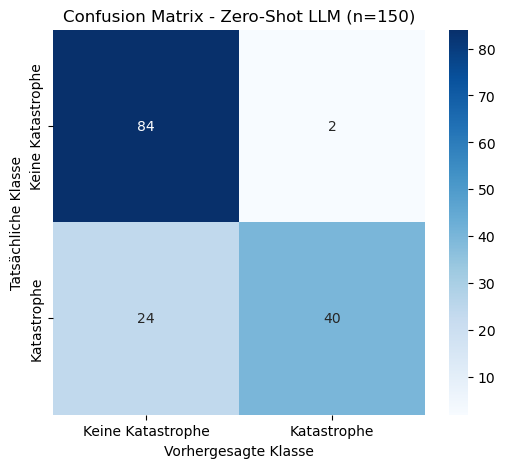

F1 (Katastrophe=1): 0.7547169811320755


In [52]:
n_eval = 150
X_val_sample, y_val_sample = stratified_sample(X_val, y_val, n_samples=n_eval, random_state=42)

if OPENAI_API_KEY is None:
    print("Zero-Shot übersprungen (kein OPENAI_API_KEY).")
else:
    zero_cache_path = os.path.join(CACHE_DIR, f"zero_shot_{n_eval}.json")
    y_pred_zero = run_llm_inference_with_cache(
        X_val_sample,
        cache_path=zero_cache_path,
        predict_fn=lambda t: llm_zero_shot_predict(t, temperature=0.0),
        sleep_s=0.0
    )

    evaluate_model(y_val_sample, y_pred_zero, title=f"Zero-Shot LLM (n={n_eval})")
    print("F1 (Katastrophe=1):", f1_score(y_val_sample, y_pred_zero, pos_label=1))

**Interpretation Zero-Shot**
Zero-Shot liefert eine hohe Precision für 'Katastrophe', aber einen deutlich tieferem Recall. 
Das deutet darauf hin, dass das LLM eher 'vorsichtig' ist und nur bei klaren Fällen 'Katastrophe' verhersagt. 

Folge: Mehr False Negatives (reale Katastrophen, die als 'keine Katastrophe' klassifiziert werden). 
Für ein Einsatzszenario, in dem keine echten Katastrophen übersehen werden sollen, wäre daher eine recall-stärkere Strategie sinnvoll (z.B. Few-Shot oder Embedding-basierte Modelle).

### 15.2 Embedding + Logistische Regression (Sentence-Transformers)

Idee: Tweets werden in semantische Vektoren (Embeddings) umgewandelt. Dadurch wird Kontext / Bedeutung in numerischer Form repräsentiert. Auf diesen Features wird eine logistische Regression trainiert. 

Vorteile: 
- effizient & reproduzierbar (kein API-Zugriff nötig)
- interpretierbarer Klassifikator (LogReg)
- häufig deutlich besser als reine Wortzählung (TF-IDF), weil Semantik enthalten ist

Ich verwende all-MiniLM-L6-v2, weil es ein kompaktes und schnelles Sentence-Transformer-Modell ist, das in der Praxis oft als starke Embedding-Baseline genutzt wird. Es liefert semantisch sinvolle Vektoren, ist lokal ohne API-Kosten ausführbar und damit gut reproduzierbar.

Batches:   0%|          | 0/96 [00:00<?, ?it/s]

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Train embeddings shape: (6090, 384)
Val embeddings shape: (1523, 384)
Embedding + LogReg (Sentence-Transformers)
                   precision    recall  f1-score   support

Keine Katastrophe       0.84      0.88      0.86       869
      Katastrophe       0.83      0.77      0.80       654

         accuracy                           0.84      1523
        macro avg       0.83      0.83      0.83      1523
     weighted avg       0.84      0.84      0.83      1523



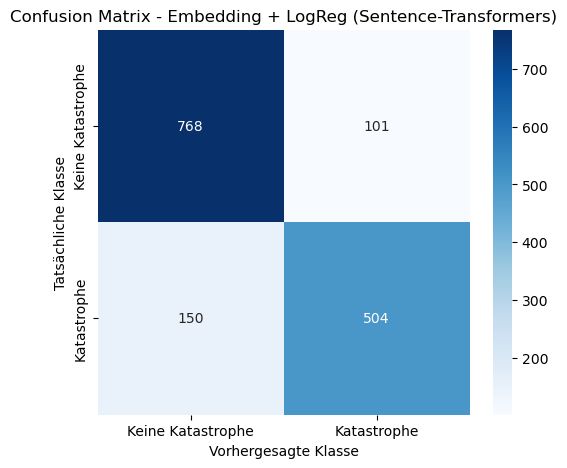

F1 (Katastrophe=1): 0.8006354249404289


In [53]:
# Falls noch nicht vorhanden:
# !pip -q install sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression

# Kompaktes, schnelles Embedding-Modell (sehr üblich)
EMB_MODEL_NAME = "all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMB_MODEL_NAME)

def embed_texts(texts, batch_size=64):
    """
    Gibt ein (n_samples, embedding_dim) Array zurück.
    """
    embs = embedder.encode(
        list(texts),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    return embs

# Embeddings berechnen
X_train_emb = embed_texts(X_train, batch_size=64)
X_val_emb = embed_texts(X_val, batch_size=64)

print("Train embeddings shape:", X_train_emb.shape)
print("Val embeddings shape:", X_val_emb.shape)

# Logistic Regression auf Embeddings
emb_logreg = LogisticRegression(
    max_iter=2000,
    solver="lbfgs"
)

emb_logreg.fit(X_train_emb, y_train)
y_pred_emb = emb_logreg.predict(X_val_emb)

evaluate_model(y_val, y_pred_emb, title="Embedding + LogReg (Sentence-Transformers)")
print("F1 (Katastrophe=1):", f1_score(y_val, y_pred_emb, pos_label=1))


In [61]:
# Mini-Fehleranalyse: Embedding + LogReg (inkl. Original-Index für Nachvollziehbarkeit)
val_emb_df = pd.DataFrame({
    "orig_idx": X_val.index,
    "text": X_val.astype(str).values,
    "true": y_val.astype(int).values,
    "pred": pd.Series(y_pred_emb).astype(int).values
})

fn = val_emb_df[(val_emb_df["true"] == 1) & (val_emb_df["pred"] == 0)]
fp = val_emb_df[(val_emb_df["true"] == 0) & (val_emb_df["pred"] == 1)]

fn_emb = fn.sample(min(5, len(fn)), random_state=42)
fp_emb = fp.sample(min(5, len(fp)), random_state=42)

pd.set_option("display.max_colwidth", None)

print("5 False Negatives (Embedding + LogReg):")
display(fn_emb[["orig_idx", "text"]])

print("5 False Positives (Embedding + LogReg):")
display(fp_emb[["orig_idx", "text"]])


5 False Negatives (Embedding + LogReg):


,orig_idx,text
624,7489,@GeorgeFoster72 and The Wreck of the Edmund Fitzgerald
142,2564,5/6 will destroy Reg C competitiveness. The entire region will B over-saturated. Yes Brockton gets $12M and RegC Commonwealth PPC and
1184,4121,Ready for my close up... Errrr nope!! #notgoingoutinthat #hailstorm #alberta @HellOnWheelsAMC @HoW_fans @TalkingHell http://t.co/9gIAXD6JTY
692,2346,Delmont's 'Onion House' Purchased After Plans For Demolition http://t.co/yojKfQeJ6s
668,3411,Kendall Jenner and Nick Jonas Are Dating and the World Might Quite Literally Explode http://t.co/pfvzVPxQGr


5 False Positives (Embedding + LogReg):


,orig_idx,text
1200,2698,Ignition Knock (Detonation) Sensor-Senso Standard KS100 http://t.co/7o4lNfBe7K http://t.co/fVZSGJtBew
729,90,???? it was an accident http://t.co/Oia5fxi4gM
943,1348,@MoFanon ?? your last retweet you would think the lion saved people from a burning buildings it's not that deep
1007,6504,10 Ways To Survive and Escape Martial Law | World http://t.co/BiuEY7bUtS http://t.co/JWQYbe4ep1
603,3594,The Five Fatal Flaws in the Iran Deal https://t.co/ztfEAd8GId via @YouTube


In [66]:
train.loc[[3411], ["text", "target", "keyword", "location"]]


,text,target,keyword,location
3411,Kendall Jenner and Nick Jonas Are Dating and the World Might Quite Literally Explode http://t.co/pfvzVPxQGr,1,explode,"Washington, D.C."


**Hinweis: Label Noise im Datensatz**
Bei der manuellen Sichtung einzelner Fehlklassifikationen zeigt sich, dass einzelne Beispiele im Originaldatensatz fragwürdige Labels enthalten. Beispielsweise ist ein dieser Tweet im Trainingsdatensatz als Katastrophe (target = 1) annotiert, obwohl inhaltlich kein reales Ereignis beschrieben wird. 
Solche Annotation-Fehler ('Label Noise') begrenzen die maximal erreichbare Modelleitsung nd erklären, warum ein Teil der False Negatives / Positives bei nährer Betrachtung nicht eindeutig sind. 

**Interpretation (Embedding + LogReg):**  
Dieser Ansatz erzielt die beste Performance unter den getesteten Methoden. Im Vergleich zur TF-IDF-Baseline profitiert das Modell davon, dass Sentence-Embeddings semantische Ähnlichkeiten abbilden (z.B. indirekte Formulierungen, Synonyme und Kontext), was besonders bei kurzen Tweets hilfreich ist.

Die Mini-Fehleranalyse zeigt zudem, dass ein Teil der verbleibenden Fehlklassifikationen nicht nur modellbedingt sind, sondern auch auf Label Noise im Datensatz zurückzuführen sein können (z.B. metaphorische Verwendung von Wörtern wie „explode“, die im Datensatz teilweise als Katastrophe annotiert sind). Das setzt eine natürliche Obergrenze für die erreichbare Modellleistung.

Damit bietet Embedding + LogReg einen sehr guten Trade-off zwischen:
- **Leistung** (höchster F1 für Klasse „Katastrophe“)  
- **Effizienz** (lokal ausführbar, keine API-Kosten)  
- **Reproduzierbarkeit & Interpretierbarkeit** (klassisches Modell auf festen Features)


### 15.3 Few-Shot Klassifikation (LLM via API)

Idee: Im Few-Shot Setting erhält das LLM zusätzlich wenige gelabelte Beispiele (z.B. 3 pro Klasse).
Dadurch kann sich das Modell besser an die konkrete Aufgabenstellung und die Definition von 'Katastrophe' im Datensatz anpassen. 

Erwartung: Few-Shot sollte insbesondere den Recall für 'Katastrophe' gegenüber Zero-Shot verbessern. 

In [67]:
def build_few_shot_examples(X_train, y_train, k_per_class=3, random_state=42):
    """
    Baut k_per_class Beispiele pro Klasse aus dem Training.
    """
    X_train = np.array(list(X_train))
    y_train = np.array(list(y_train))

    rng = np.random.default_rng(random_state)

    examples = []
    for cls in [0, 1]:
        idx = np.where(y_train == cls)[0]
        chosen = rng.choice(idx, size=min(k_per_class, len(idx)), replace=False)
        for i in chosen:
            examples.append((X_train[i], int(y_train[i])))

    # Mischen, damit nicht zuerst nur 0 dann 1 kommt
    rng.shuffle(examples)
    return examples


def llm_few_shot_predict(text, few_shot_examples, temperature=0.0):
    """
    Few-shot: LLM bekommt Beispiele und klassifiziert neuen Tweet.
    Antwort muss 0/1 sein.
    """
    system_msg = (
        "Du bist ein Klassifikationssystem. "
        "Du entscheidest, ob ein Tweet eine reale Katastrophe beschreibt (1) oder nicht (0). "
        "Antworte ausschliesslich mit einer einzigen Ziffer: 0 oder 1."
    )

    examples_block = "Beispiele:\n"
    for ex_text, ex_label in few_shot_examples:
        examples_block += f"- Tweet: {ex_text}\n  Label: {ex_label}\n"

    user_msg = (
        f"{examples_block}\n"
        "Nun klassifiziere folgenden Tweet.\n\n"
        f"Tweet: {text}\n\n"
        "Antwort (nur 0 oder 1):"
    )

    resp = client.chat.completions.create(
        model=LLM_MODEL,
        temperature=temperature,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
    )

    out = resp.choices[0].message.content.strip()

    if "1" in out and "0" not in out:
        return 1
    if "0" in out and "1" not in out:
        return 0

    for ch in out:
        if ch in ["0", "1"]:
            return int(ch)

    return 0


Few-Shot LLM (n=150, k_per_class=3)
                   precision    recall  f1-score   support

Keine Katastrophe       0.84      0.98      0.90        86
      Katastrophe       0.96      0.75      0.84        64

         accuracy                           0.88       150
        macro avg       0.90      0.86      0.87       150
     weighted avg       0.89      0.88      0.88       150



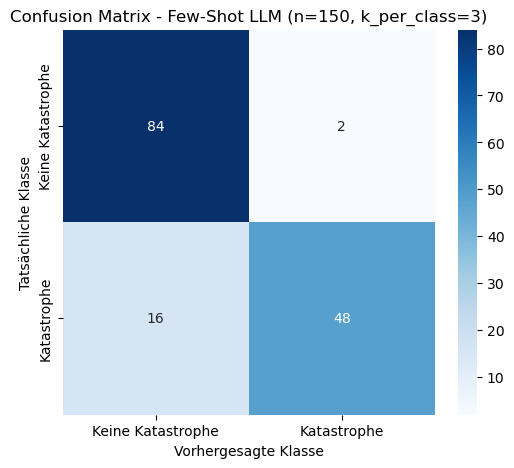

F1 (Katastrophe=1): 0.8421052631578947


In [68]:
n_eval = 150
X_val_sample, y_val_sample = stratified_sample(X_val, y_val, n_samples=n_eval, random_state=42)

if OPENAI_API_KEY is None:
    print("Few-Shot übersprungen (kein OPENAI_API_KEY).")
else:
    few_shot_examples = build_few_shot_examples(X_train, y_train, k_per_class=3, random_state=42)
    few_cache_path = os.path.join(CACHE_DIR, f"few_shot_{n_eval}.json")

    y_pred_few = run_llm_inference_with_cache(
        X_val_sample,
        cache_path=few_cache_path,
        predict_fn=lambda t: llm_few_shot_predict(t, few_shot_examples=few_shot_examples, temperature=0.0),
        sleep_s=0.2
    )

    evaluate_model(y_val_sample, y_pred_few, title=f"Few-Shot LLM (n={n_eval}, k_per_class=3)")
    print("F1 (Katastrophe=1):", f1_score(y_val_sample, y_pred_few, pos_label=1))


**Intepretation Few-Shot:**

Few-Shot verbessert gegenüber Zero-Shot die Erkennung realer Katastrophen, da das Modell durch Beispiele stärker 'kalibriert' wird. 
Gleichzeiting bleibt Embedding + LogReg im direkten Vergleich leistungsstärker und ist zudem ohne API-Kosten reproduzierbar.

Few-Shot ist damit vor allem als schneller LLM-Vergleich sinnvoll, während Embedding + LogReg für das Projekt die robustere Hauptlösung darstellt.

## 16. Vergleich der Ansätze

Zum Abschluss werden die Modelle anhand des F1-Scores für die Klasse Katastrophe verglichen. 
Dabei wird zusätzlich qualitativ bewertet, wie hoch der Aufwand und dir Reproduzierbarkeit der jeweilige Methode ist. 

In [69]:
results = []

# Baseline neu ausrechnen (falls baseline_model noch im Notebook existiert)
try:
    y_pred_base = baseline_model.predict(X_val)
    results.append(("TF-IDF + LogReg", f1_score(y_val, y_pred_base, pos_label=1)))
except NameError:
    pass

# Bi-LSTM falls vorhanden
try:
    results.append(("Bi-LSTM + GloVe", f1_score(y_val, y_val_pred_nn, pos_label=1)))
except NameError:
    pass

# Embedding + LogReg
try:
    results.append(("Embedding + LogReg", f1_score(y_val, y_pred_emb, pos_label=1)))
except NameError:
    pass

# Zero-/Few-shot nur wenn gelaufen
try:
    results.append((f"LLM Zero-Shot (n={n_eval})", f1_score(y_val_sample, y_pred_zero, pos_label=1)))
except Exception:
    pass

try:
    results.append((f"LLM Few-Shot (n={n_eval})", f1_score(y_val_sample, y_pred_few, pos_label=1)))
except Exception:
    pass

results_df = pd.DataFrame(results, columns=["Modell", "F1 (Katastrophe=1)"]).sort_values("F1 (Katastrophe=1)", ascending=False)
results_df


,Modell,F1 (Katastrophe=1)
4,LLM Few-Shot (n=150),0.842105
2,Embedding + LogReg,0.800635
0,TF-IDF + LogReg,0.764755
3,LLM Zero-Shot (n=150),0.754717
1,Bi-LSTM + GloVe,0.750853


## Fazit & Vergleich der Ansätze

Zum Abschluss wurden fünf Ansätze anhand des **F1-Scores für die Klasse „Katastrophe“ (Label = 1)** verglichen. Zusätzlich wurde qualitativ bewertet, wie hoch der Implementationsaufwand ist und wie gut sich die Methode reproduzieren lässt.

### Zusammenfassung der Ergebnisse (quantitativ)
- **LLM Few-Shot** erzielt im Vergleich den höchsten F1-Score auf dem evaluierten Sample. Dies deutet darauf hin, dass Beispiele im Prompt die Klassifikation besser kalibrieren können als Zero-Shot.
- **Embedding + LogReg (Sentence-Transformer)** erreicht ebenfalls sehr starke Werte und ist unter den lokal ausführbaren Methoden der beste Ansatz.
- **TF-IDF + LogReg (Baseline)** liefert eine solide Referenzleistung, ist sehr effizient, verpasst jedoch häufiger semantisch indirekte Formulierungen.
- **Bi-LSTM + GloVe** verbessert die Baseline nicht klar, verursacht aber deutlich höheren Trainingsaufwand (Training, Hyperparameter, Reproduzierbarkeit).
- **LLM Zero-Shot** ist schnell einsetzbar, tendiert jedoch in diesem Setup zu konservativen Vorhersagen (tendenziell geringerer Recall → echte Katastrophen werden eher übersehen).

### Aufwand, Reproduzierbarkeit und Praxistauglichkeit (qualitativ)
- **Embedding + LogReg** bietet den besten Gesamt-Trade-off:
  - **Effizient & lokal** ausführbar (keine API-Kosten, keine GPU nötig)
  - **Gut reproduzierbar** (deterministischer Workflow, wenig externe Abhängigkeiten)
  - **Starke Leistung** dank semantischer Embeddings
- **LLM-Ansätze** sind konzeptionell attraktiv, aber im Projektkontext eingeschränkt reproduzierbar:
  - Ergebnisse hängen von Modellversion, Prompting und API-Verfügbarkeit ab
  - Zusätzlich entstehen Kosten, weshalb nur ein Sample evaluiert wurde

### Fehlerbilder & Datensatzlimitationen
Die manuelle Fehleranalyse zeigt, dass ein Teil der Fehlklassifikationen auf **Ambiguität und Label Noise im Datensatz** zurückzuführen sein kann (z.B. metaphorische Nutzung von Wörtern wie „explode“). Solche Fälle setzen eine natürliche Obergrenze für die erreichbare Modellleistung, unabhängig vom Modell.

### Endgültige Modellwahl
Für dieses Projekt ist **Embedding + LogReg** der überzeugendste Ansatz, weil er **Leistung, Aufwand und Reproduzierbarkeit** am besten vereint.  
Der LLM Few-Shot Ansatz erreicht zwar auf dem Sample die beste F1-Performance, ist jedoch aufgrund von **API-Abhängigkeit und Kosten** weniger geeignet als reproduzierbare Standardlösung.

### Mögliche nächste Schritte
- **Threshold-Tuning** zur gezielten Recall-Optimierung (False Negatives reduzieren)
- **Fine-Tuning eines Transformers** (z.B. DistilBERT) auf dem Datensatz
- Einbezug zusätzlicher Features wie **keyword/location** oder leichte **Cross-Validation** für robustere Schätzung
